# １章１節６項 レンジマイグレーション

## 概要
レンジマイグレーションによる影響とその補正の可視化です。

## 使用データ

| 項目 | 使用データなし |
| ---- | ---- |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

PATH_OUTPUT = 'output/1_1_6/'
os.makedirs(PATH_OUTPUT, exist_ok=True)

In [2]:
# Examples Parameters
num_sample = 1024 * 4
num_length = 2048

alpha = 1.1 # curve parameter

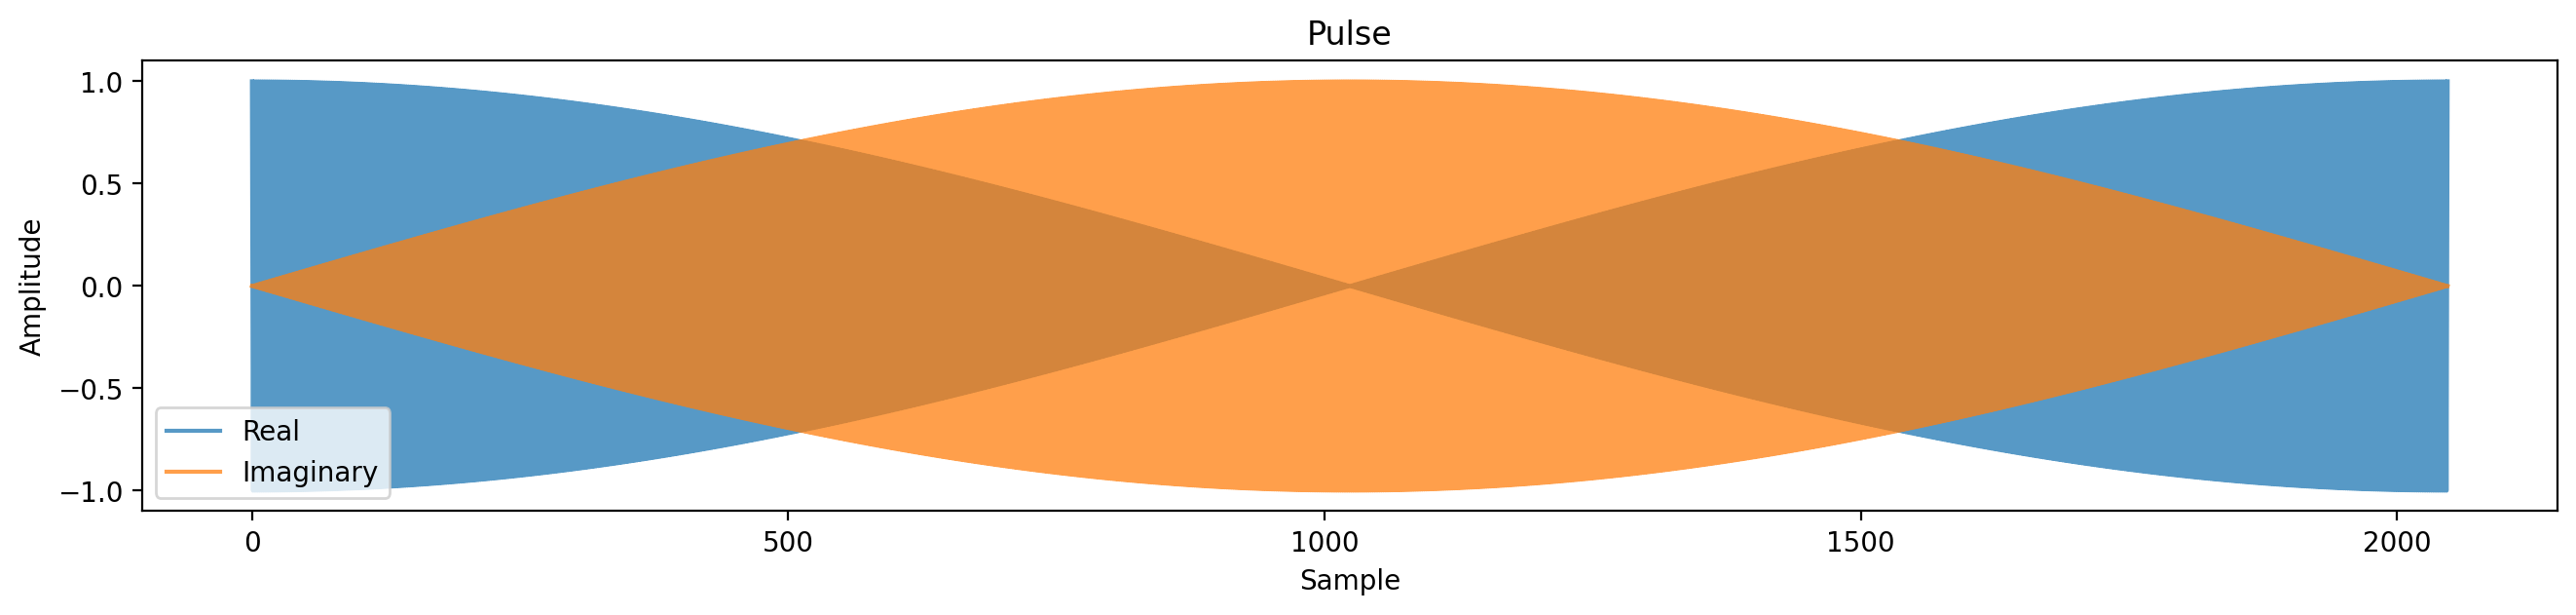

In [3]:
pulse_sample = 128
pulse_times = np.linspace(0, num_length, num_length)
pulse = np.exp(1j * np.pi * pulse_times)

plt.figure(figsize=(16, 3), dpi=200, facecolor='w', edgecolor='k')
plt.title('Pulse')
plt.plot(pulse.real, label='Real', alpha=0.75)
plt.plot(pulse.imag, label='Imaginary', alpha=0.75)
plt.legend()
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.savefig(os.path.join(PATH_OUTPUT, f'section_06_001_pulse.png'), bbox_inches='tight')
plt.show()

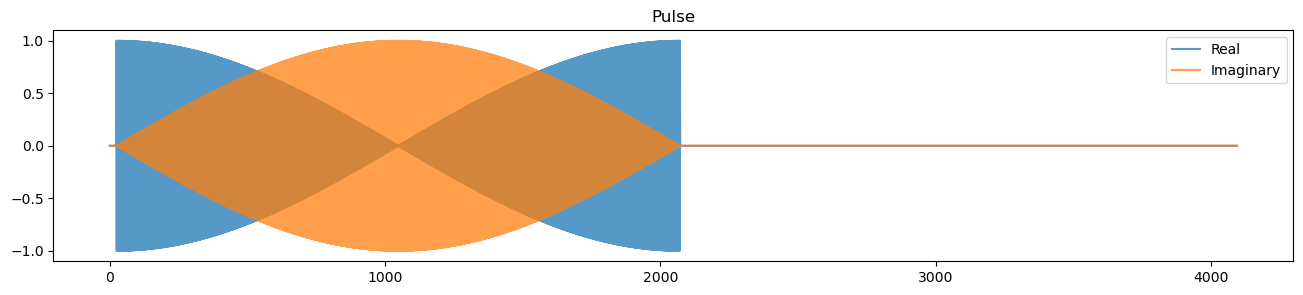

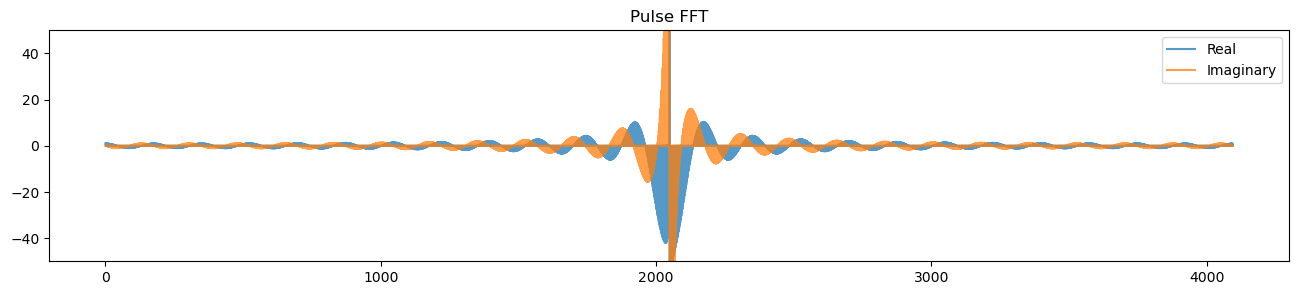

In [4]:
pulse_ra_filter = np.zeros((num_sample,), dtype=np.complex64)
tx_offset = 24
pulse_ra_filter[tx_offset:num_length+tx_offset] = pulse

plt.figure(figsize=(16, 3), dpi=100, facecolor='w', edgecolor='k')
plt.title('Pulse')
plt.plot(pulse_ra_filter.real, label='Real', alpha=0.75)
plt.plot(pulse_ra_filter.imag, label='Imaginary', alpha=0.75)
plt.legend()

pulse_ra_filter_fft = np.fft.fft(pulse_ra_filter, axis=0)

plt.figure(figsize=(16, 3), dpi=100, facecolor='w', edgecolor='k')
plt.title('Pulse FFT')
plt.plot(pulse_ra_filter_fft.real, label='Real', alpha=0.75)
plt.plot(pulse_ra_filter_fft.imag, label='Imaginary', alpha=0.75)
plt.ylim(-50, 50)
plt.legend()

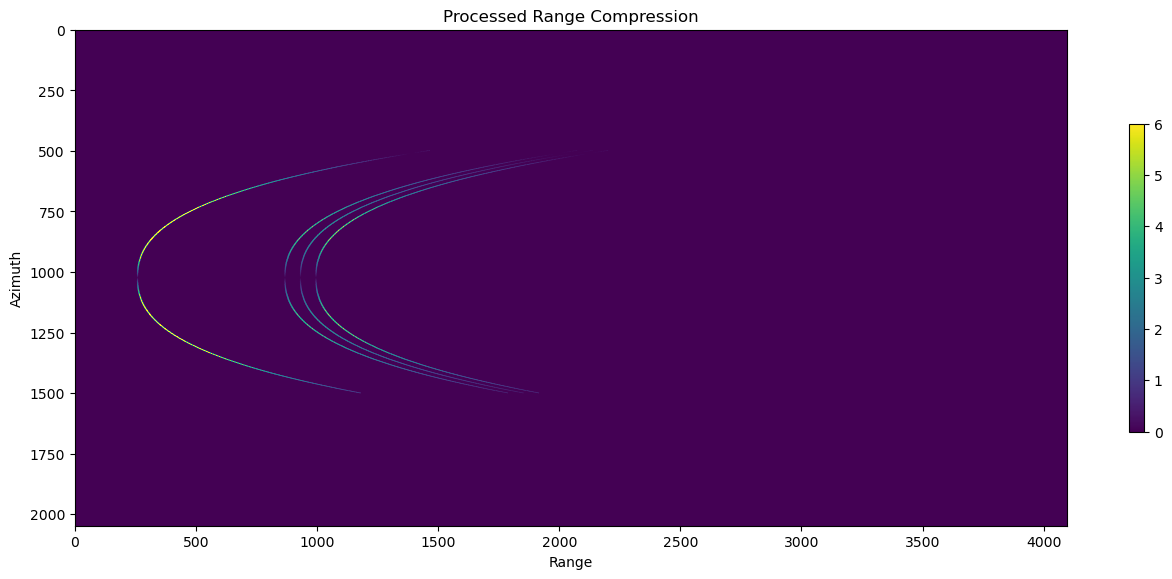

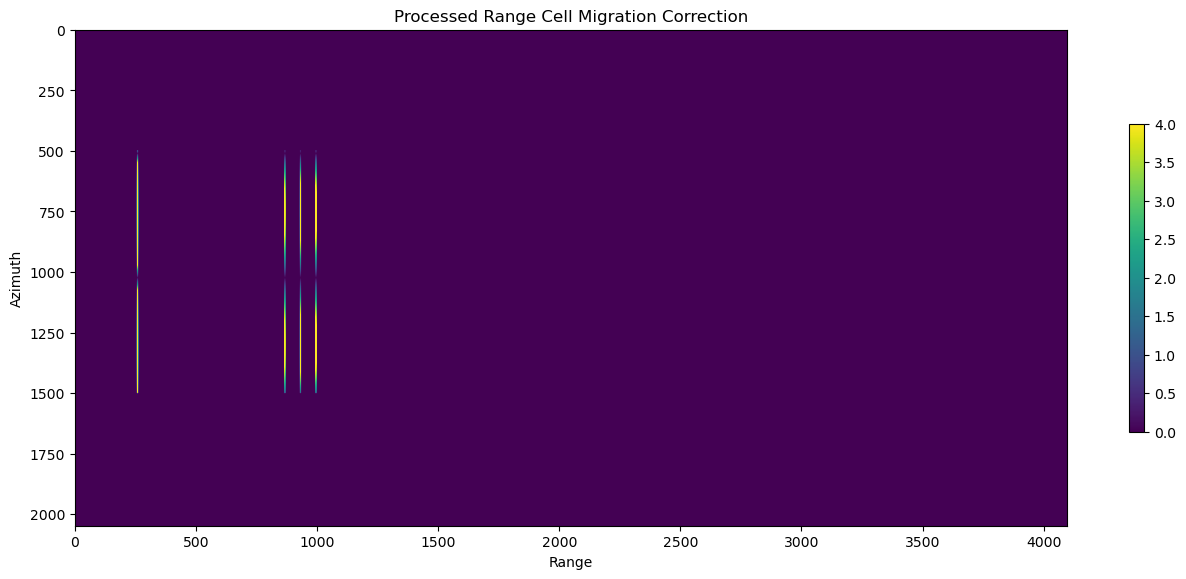

In [6]:
rcm_i = np.load('../data/migration/section_06_002_target_rcm_i.npy')
rcm_q = np.load('../data/migration/section_06_002_target_rcm_q.npy')

rcm = rcm_i + 1j * rcm_q

# range cell migration correction
rcmc = np.zeros_like(rcm)
for i in range(num_length):
    rcmc[i, :] = np.roll(rcm[i,:], -int((abs(1024 - i)**(alpha + abs(1024 - i)/(1024 * 4)))))
    rcmc[i, :] = np.roll(rcmc[i, :], int((abs(1024 - i)**(alpha))))
    
plt.figure(figsize=(16, 8), dpi=100, facecolor='w', edgecolor='k')
plt.imshow(np.abs(rcm), vmax=6)
plt.title('Processed Range Compression')
plt.xlabel('Range')
plt.ylabel('Azimuth')
plt.colorbar(shrink=0.5)
plt.savefig(os.path.join(PATH_OUTPUT, f'section_06_003_target_azimuth_rcm.png'), bbox_inches='tight')

plt.figure(figsize=(16, 8), dpi=100, facecolor='w', edgecolor='k')
plt.imshow(np.abs(rcmc), vmax=4)
plt.title('Processed Range Cell Migration Correction')
plt.xlabel('Range')
plt.ylabel('Azimuth')
plt.colorbar(shrink=0.5)
plt.savefig(os.path.join(PATH_OUTPUT, f'section_06_004_target_azimuth_rcmc.png'), bbox_inches='tight')

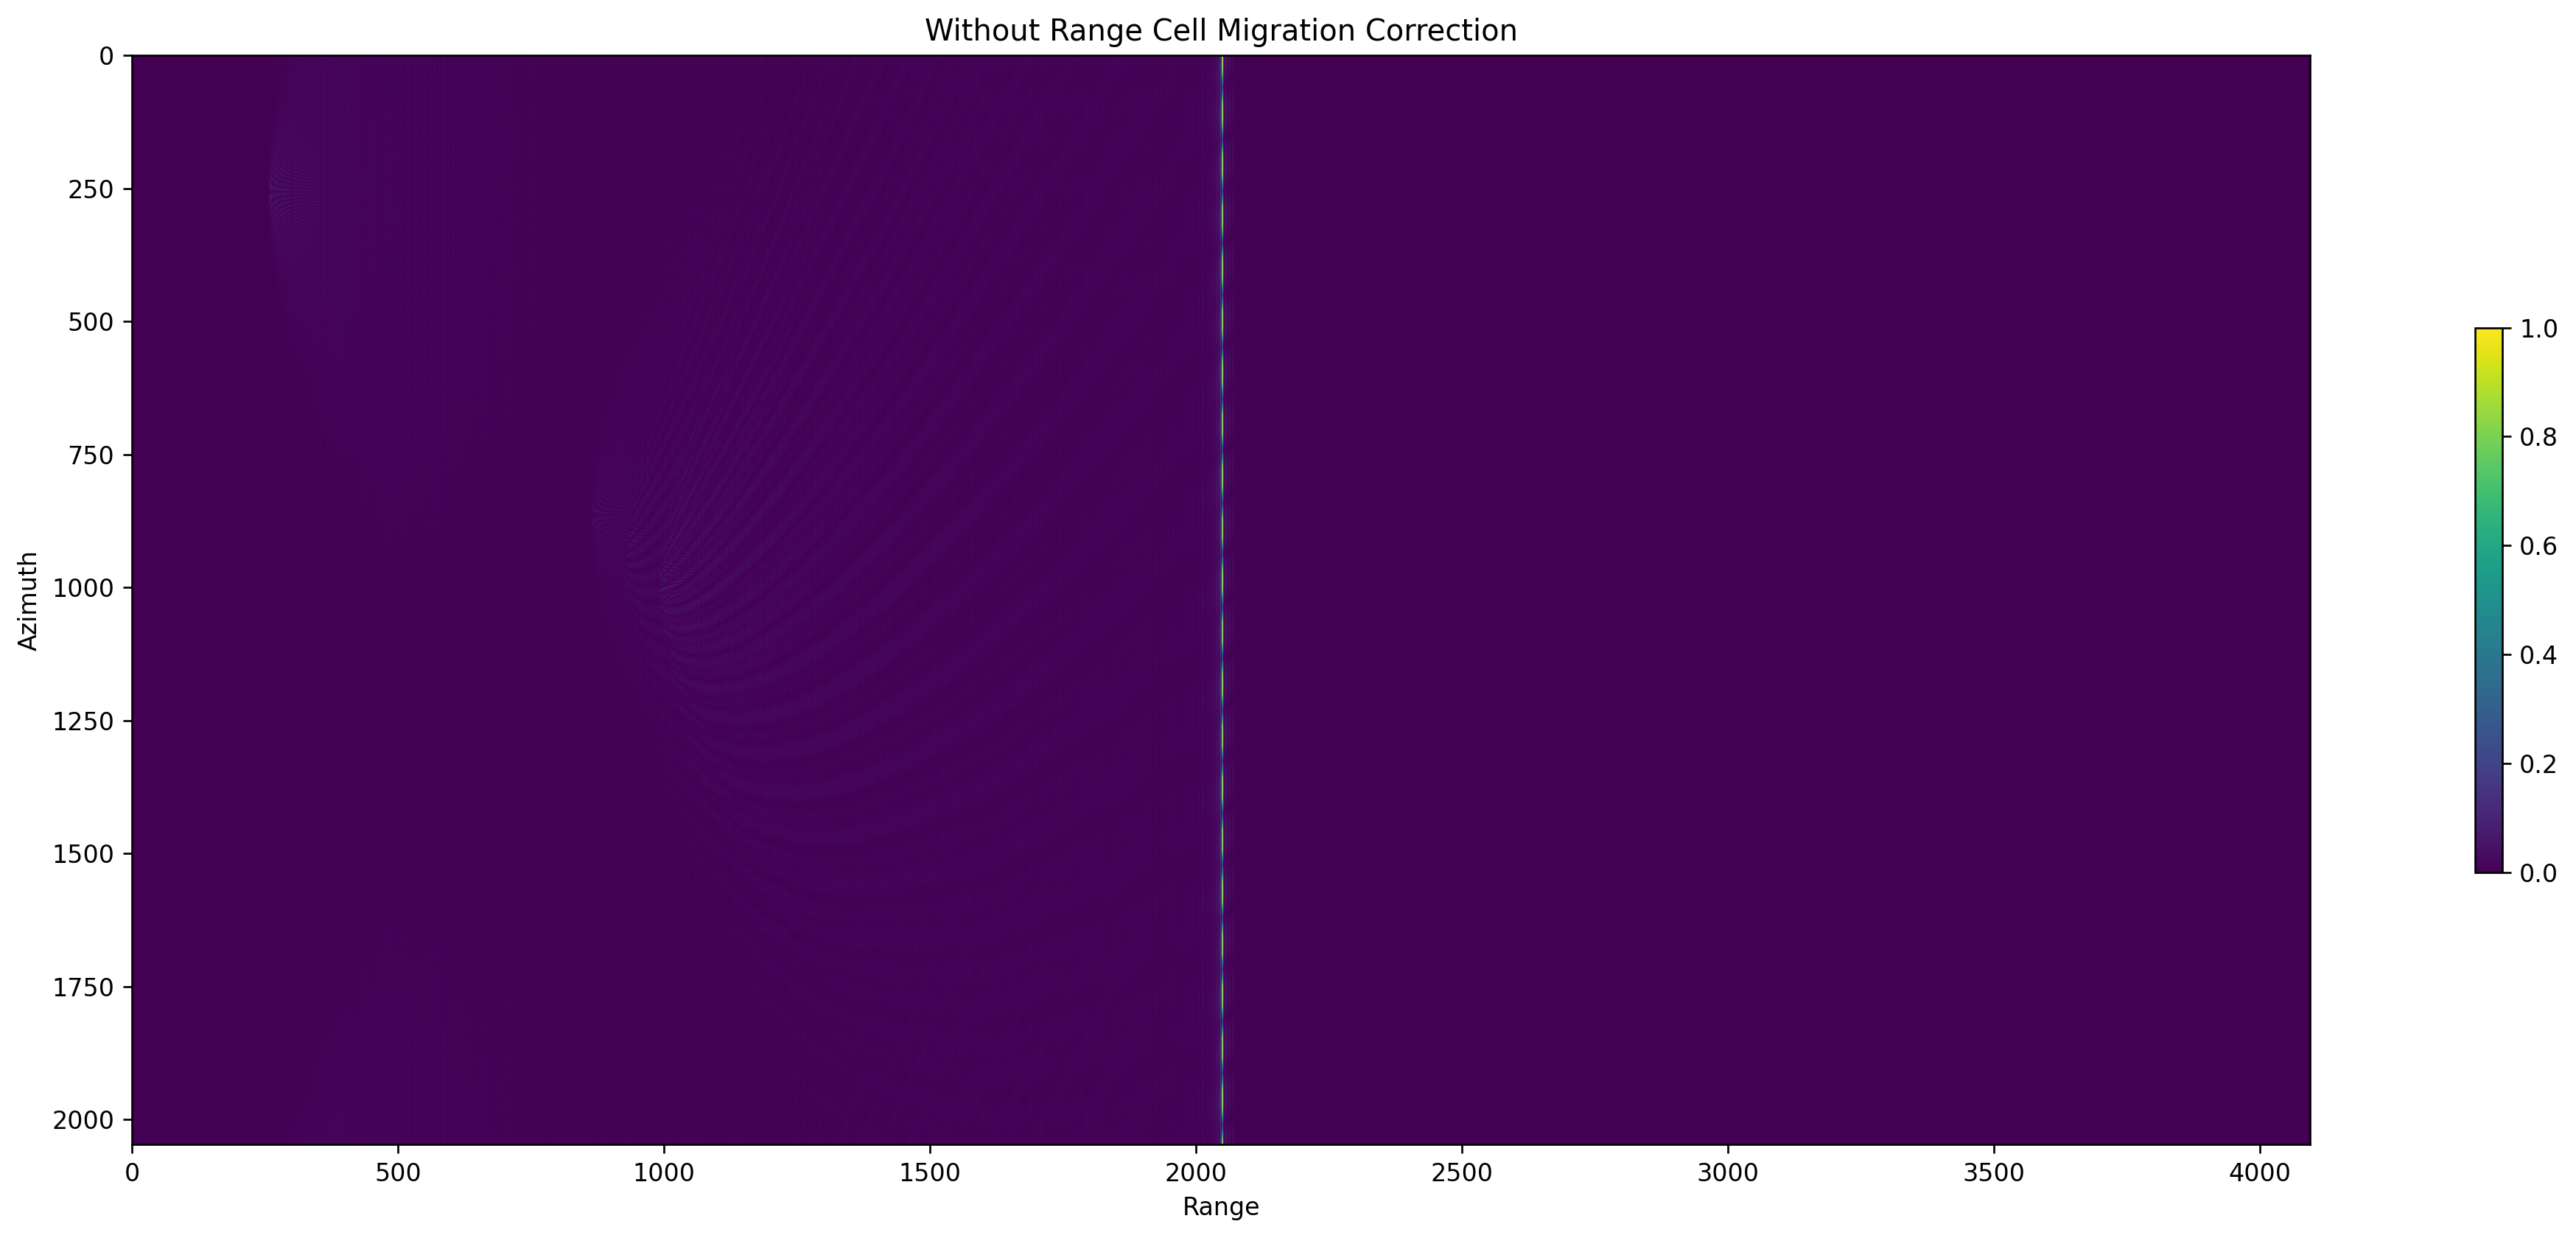

In [7]:
comp = np.fft.ifft(rcm * np.conj(pulse_ra_filter_fft), axis=0)

plt.figure(figsize=(24, 8), dpi=240, facecolor='w', edgecolor='k')
plt.imshow(np.abs(comp), vmax=1)
plt.title('Without Range Cell Migration Correction')
plt.colorbar(shrink=0.5)
plt.xlabel('Range')
plt.ylabel('Azimuth')
plt.savefig(os.path.join(PATH_OUTPUT, f'section_06_005_target_azimuth_rcm.png'), bbox_inches='tight')

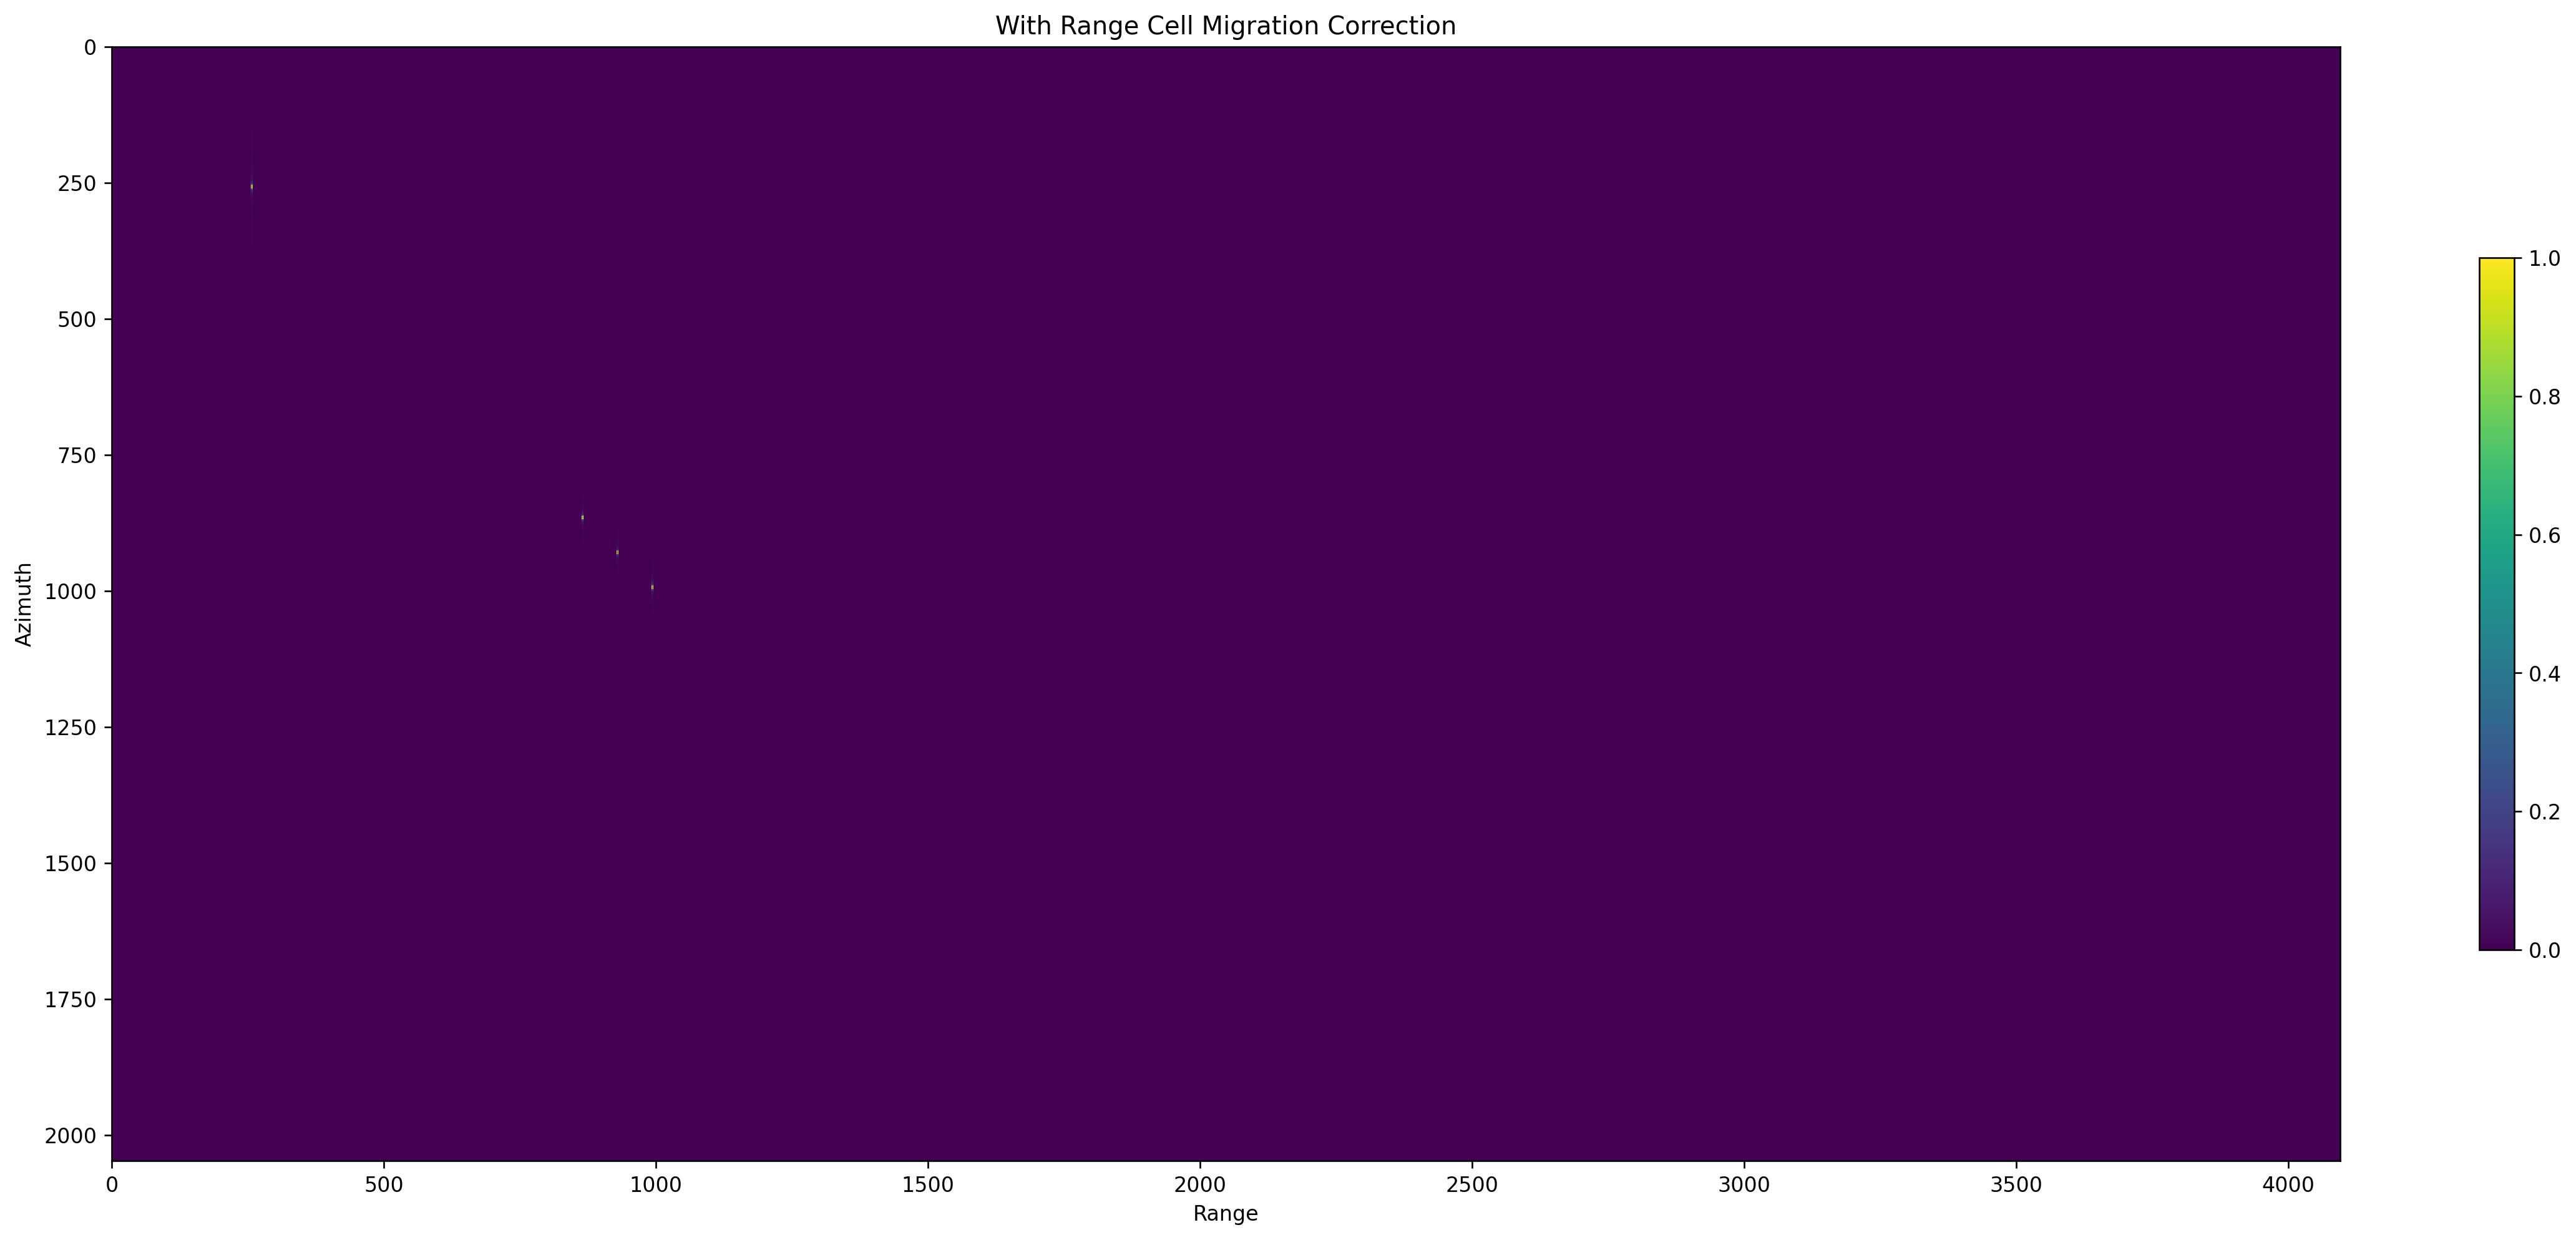

In [8]:
comp = np.fft.ifft(rcmc * np.conj(pulse_ra_filter_fft), axis=0)

plt.figure(figsize=(24, 12), dpi=240, facecolor='w', edgecolor='k')
plt.imshow(np.abs(comp), vmax=1)
plt.title('With Range Cell Migration Correction')
plt.colorbar(shrink=0.5)
plt.xlabel('Range')
plt.ylabel('Azimuth')
plt.savefig(os.path.join(PATH_OUTPUT, f'section_06_006_target_azimuth_rcmc.png'), bbox_inches='tight')